In [1]:
# CodeAlpha Internship — Task 2: Exploratory Data Analysis

## E-Commerce Book Dataset EDA

#This project explores the book dataset collected during Task 1. 
#The goal is to understand the data, identify patterns, and find useful insights about book prices, ratings, categories, and availability.

In [2]:
# Let's import the libraries we need for the analysis

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the book dataset we created in Task 1

df = pd.read_csv("../data/books_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Let's get a quick look at the dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1000
Columns: 6


,Title,Product_URL,Price_GBP,Rating,Availability,Category
0,A Light in the Attic,https://books.toscrape.com/catalogue/a-light-i...,51.77,Three,In stock,Poetry
1,Tipping the Velvet,https://books.toscrape.com/catalogue/tipping-t...,53.74,One,In stock,Historical Fiction
2,Soumission,https://books.toscrape.com/catalogue/soumissio...,50.10,One,In stock,Fiction
3,Sharp Objects,https://books.toscrape.com/catalogue/sharp-obj...,47.82,Four,In stock,Mystery
4,Sapiens: A Brief History of Humankind,https://books.toscrape.com/catalogue/sapiens-a...,54.23,Five,In stock,History


In [5]:
# Let's check what type of data is stored in each column

print(df.dtypes)

Title               str
Product_URL         str
Price_GBP       float64
Rating              str
Availability        str
Category            str
dtype: object


In [6]:
# Let's check if there are any missing values in the dataset

missing_values = df.isnull().sum()

print(missing_values)

Title           0
Product_URL     0
Price_GBP       0
Rating          0
Availability    0
Category        0
dtype: int64


In [7]:
# Let's check if any rows are duplicated

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [8]:
# Let's look at some basic statistics about the book prices

df.describe()

,Price_GBP
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [9]:
# Let's see how the books are distributed by rating

rating_counts = df["Rating"].value_counts()

print(rating_counts)

Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [10]:
# Let's see how many books are in each category

category_counts = df["Category"].value_counts()

print(category_counts.head(10))

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64


In [11]:
# Let's take a closer look at the book prices

average_price = df["Price_GBP"].mean()
cheapest_price = df["Price_GBP"].min()
most_expensive_price = df["Price_GBP"].max()

print(f"Average price: £{average_price:.2f}")
print(f"Cheapest price: £{cheapest_price:.2f}")
print(f"Most expensive price: £{most_expensive_price:.2f}")

Average price: £35.07
Cheapest price: £10.00
Most expensive price: £59.99


In [12]:
# Let's find the cheapest and most expensive books

cheapest = df.loc[df["Price_GBP"].idxmin()]
most_expensive = df.loc[df["Price_GBP"].idxmax()]

print("Cheapest book:", cheapest["Title"])
print("Price: £", cheapest["Price_GBP"])

print()
print("Most expensive book:", most_expensive["Title"])
print("Price: £", most_expensive["Price_GBP"])

Cheapest book: An Abundance of Katherines
Price: £ 10.0

Most expensive book: The Perfect Play (Play by Play #1)
Price: £ 59.99


In [13]:
# Let's see which categories have the most books

top_categories = df["Category"].value_counts().head(5)

print(top_categories)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Name: count, dtype: int64


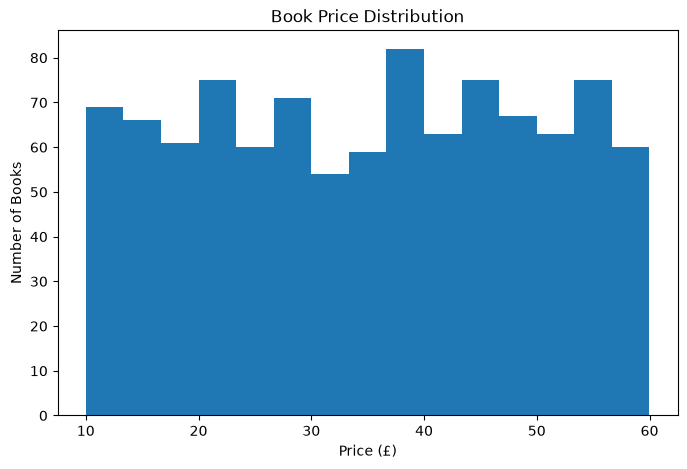

In [14]:
# Let's see how the book prices are spread out

df["Price_GBP"].plot(
    kind="hist",
    bins=15,
    figsize=(8, 5),
    title="Book Price Distribution"
)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

In [15]:
# Let's see the average price for each rating

rating_prices = df.groupby("Rating")["Price_GBP"].mean()

print(rating_prices)

Rating
Five     35.374490
Four     36.093296
One      34.561195
Three    34.692020
Two      34.810918
Name: Price_GBP, dtype: float64


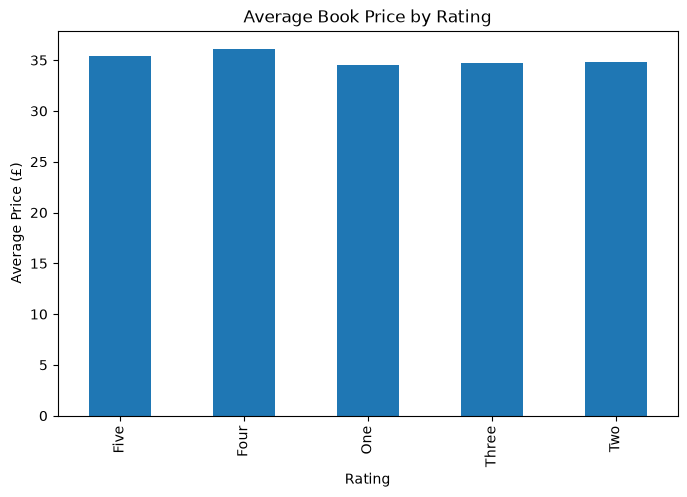

In [16]:
# Let's make a simple chart to compare the ratings

rating_prices.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Book Price by Rating"
)

plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.show()

In [17]:
# Let's see which categories have the highest average prices

category_prices = df.groupby("Category")["Price_GBP"].mean()

print(category_prices.sort_values(ascending=False).head(10))

Category
Suspense            58.330000
Novels              54.810000
Politics            53.613333
Health              51.452500
New Adult           46.383333
Christian           42.496667
Sports and Games    41.166000
Self Help           40.620000
Travel              39.794545
Fantasy             39.593958
Name: Price_GBP, dtype: float64


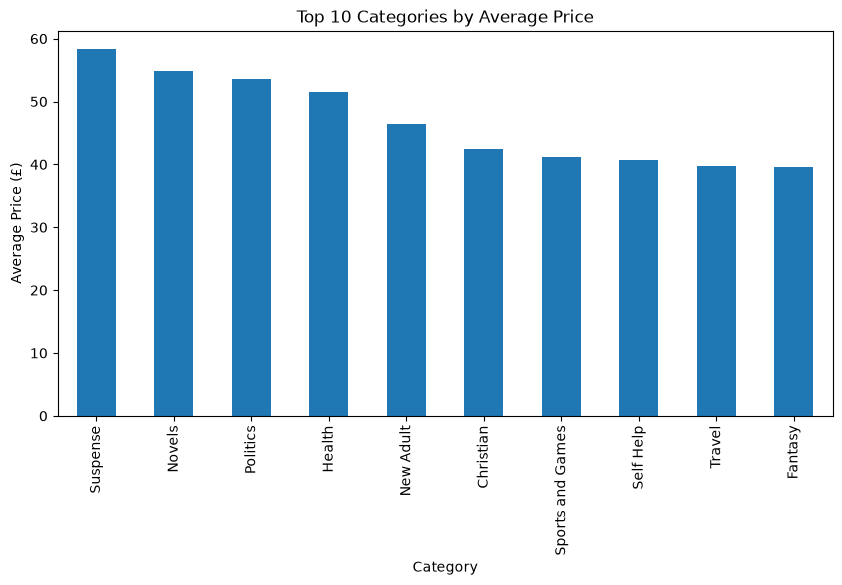

In [18]:
# Let's make a chart for the most expensive categories

top_category_prices = category_prices.sort_values(ascending=False).head(10)

top_category_prices.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Categories by Average Price"
)

plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.show()

In [19]:
# Let's see how many books are in stock

availability = df["Availability"].value_counts()

print(availability)

Availability
In stock    1000
Name: count, dtype: int64


In [20]:
# Let's see how many different categories we have

number_of_categories = df["Category"].nunique()

print("Number of categories:", number_of_categories)

Number of categories: 50


In [21]:
# Let's see which category has the most books

most_common_category = df["Category"].value_counts().idxmax()
number_of_books = df["Category"].value_counts().max()

print("Most common category:", most_common_category)
print("Number of books:", number_of_books)

Most common category: Default
Number of books: 152


In [22]:
# Let's see which category has the highest average price

most_expensive_category = category_prices.idxmax()
highest_average_price = category_prices.max()

print("Most expensive category:", most_expensive_category)
print("Average price: £", round(highest_average_price, 2))

Most expensive category: Suspense
Average price: £ 58.33


In [23]:
# Let's compare the average prices for different ratings

rating_prices = df.groupby("Rating")["Price_GBP"].mean()
rating_prices = rating_prices.sort_values(ascending=False)

print(rating_prices)

Rating
Four     36.093296
Five     35.374490
Two      34.810918
Three    34.692020
One      34.561195
Name: Price_GBP, dtype: float64


In [24]:
## Key Findings

#- The dataset contains **1,000 books** and **6 columns**.
#- There are **no missing values** in the dataset.
#- There are **no duplicate rows**.
#- The average book price is around **£35.07**.
#- Book prices range from **£10.00 to £59.99**.
#- There are **50 different book categories**.
#- **Default** is the most common category, with 152 books.
#- **One-star** books are the most common rating, with 226 books.
#- All 1,000 books are listed as **In stock**.
#- The average price is different across book ratings and categories.

In [25]:
## Conclusion

#In this analysis, I explored the book dataset collected during Task 1. 
#I looked at the structure of the data, checked for missing and duplicate values, and analyzed book prices, ratings, categories, and availability.

#The analysis helped me understand the main patterns in the dataset and showed how exploratory data analysis can be used to turn raw data into useful information.

#Overall, this task gave me more practice with Pandas, basic data analysis, and data visualization using Python.